In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
def create_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),   # 28x28 → 784
        layers.Dense(128, activation='relu'),   # Hidden layer 1
        layers.Dense(64, activation='relu'),    # Hidden layer 2
        layers.Dense(10, activation='softmax')  # Output layer
    ])
    return model

In [ ]:
model_fixed = create_model()

model_fixed.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Fixed LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8655 - loss: 0.4721 - val_accuracy: 0.9575 - val_loss: 0.1466
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9658 - loss: 0.1136 - val_accuracy: 0.9645 - val_loss: 0.1180
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9770 - loss: 0.0724 - val_accuracy: 0.9729 - val_loss: 0.0955
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9840 - loss: 0.0513 - val_accuracy: 0.9689 - val_loss: 0.1080
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9861 - loss: 0.0416 - val_accuracy: 0.9675 - val_loss: 0.1154
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9906 - loss: 0.0306 - val_accuracy: 0.9756 - val_loss: 0.0938
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9925 - loss: 0.0242 - val_accuracy: 0.9744 - val_loss: 0.0964
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9926 - loss: 0.0199 -

In [ ]:
def lr_scheduler(epoch, lr):
    if epoch > 5:
        return lr * 0.5   # Reduce LR after 5 epochs
    return lr

lr_callback = keras.callbacks.LearningRateScheduler(lr_scheduler)

model_sched = create_model()

model_sched.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sched = model_sched.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[lr_callback]   # Apply scheduler
)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8680 - loss: 0.4591 - val_accuracy: 0.9603 - val_loss: 0.1360 - learning_rate: 0.0010
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9653 - loss: 0.1196 - val_accuracy: 0.9658 - val_loss: 0.1178 - learning_rate: 0.0010
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9763 - loss: 0.0773 - val_accuracy: 0.9693 - val_loss: 0.1014 - learning_rate: 0.0010
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9822 - loss: 0.0566 - val_accuracy: 0.9682 - val_loss: 0.1112 - learning_rate: 0.0010
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9852 - loss: 0.0463 - val_accuracy: 0.9683 - val_loss: 0.1112 - learning_rate: 0.0010
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.9720 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9940 - l

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',       # Monitor validation loss
    patience=3,               # Stop if no improvement for 3 epochs
    restore_best_weights=True
)

model_early = create_model()

model_early.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_early = model_early.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]   # Apply early stopping
)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8643 - loss: 0.4651 - val_accuracy: 0.9613 - val_loss: 0.1352
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9638 - loss: 0.1205 - val_accuracy: 0.9675 - val_loss: 0.1073
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9768 - loss: 0.0775 - val_accuracy: 0.9713 - val_loss: 0.0953
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9823 - loss: 0.0561 - val_accuracy: 0.9752 - val_loss: 0.0903
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9866 - loss: 0.0410 - val_accuracy: 0.9750 - val_loss: 0.0901
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9885 - loss: 0.0344 - val_accuracy: 0.9707 - val_loss: 0.1066
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9907 - loss: 0.0286 - val_accuracy: 0.9761 - val_loss: 0.0923
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9941 - loss: 0.0209 - 

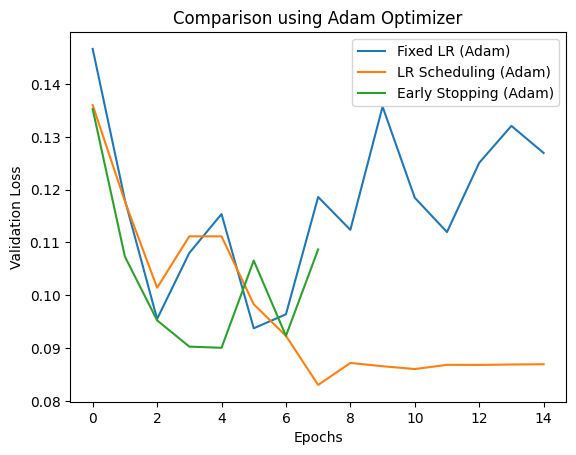

In [ ]:
plt.plot(history_fixed.history['val_loss'], label='Fixed LR (Adam)')
plt.plot(history_sched.history['val_loss'], label='LR Scheduling (Adam)')
plt.plot(history_early.history['val_loss'], label='Early Stopping (Adam)')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Comparison using Adam Optimizer")
plt.show()